In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import warnings
warnings.filterwarnings('ignore')

print("Dependencies imported successfully")

Dependencies imported successfully


Data Loading

In [62]:
def load_and_preprocess_data(csv_file_path):
    """
    Load and preprocess Chevron closing price data
    """
    df = pd.read_csv("/content/sample_data/dc dataset final.csv")
    df.columns = df.columns.str.strip()

    # Convert date and sort
    df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y', errors='coerce')
    df = df.sort_values('Date').reset_index(drop=True)

    # Extract and clean price data
    price_col = 'Adj Close Chevron stock'
    df[price_col] = df[price_col].astype(str).str.replace(',', '').str.replace('"', '')
    df[price_col] = pd.to_numeric(df[price_col], errors='coerce')
    df = df.dropna(subset=[price_col])

    prices = df[price_col].values
    dates = df['Date'].values

    print(f"Dataset loaded: {len(prices)} data points")
    print(f"Price range: ${prices.min():.2f} - ${prices.max():.2f}")

    return prices, dates

# Load data
try:
    prices, dates = load_and_preprocess_data("dc dataset final.csv")
    print("Data loaded successfully")
except Exception as e:
    print(f"Error loading data: {e}")
    prices, dates = None, None


Dataset loaded: 1257 data points
Price range: $49.74 - $104.32
Data loaded successfully


Data processing

In [63]:
def prepare_data(prices, sequence_length=15, train_size=0.8):
    """
    Prepare data for GRU training with proper scaling
    """
    # Reshape prices for scaling
    prices = prices.reshape(-1, 1)

    # Scale data to 0-1 range
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_prices = scaler.fit_transform(prices)

    # Create sequences
    X, y = [], []
    for i in range(sequence_length, len(scaled_prices)):
        X.append(scaled_prices[i-sequence_length:i, 0])
        y.append(scaled_prices[i, 0])

    X, y = np.array(X), np.array(y)

    # Split into train and test
    train_size = int(len(X) * train_size)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]

    # Reshape X for GRU (samples, time_steps, features)
    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

    print(f"Training data shape: X_train {X_train.shape}, y_train {y_train.shape}")
    print(f"Testing data shape: X_test {X_test.shape}, y_test {y_test.shape}")
    print(f"Scaled price range: {scaled_prices.min():.4f} to {scaled_prices.max():.4f}")

    return X_train, X_test, y_train, y_test, scaler

# Prepare data if prices are loaded
if prices is not None:
    X_train, X_test, y_train, y_test, scaler = prepare_data(prices)
    print("Data preparation completed")
else:
    print("Cannot prepare data - prices not loaded")


Training data shape: X_train (993, 15, 1), y_train (993,)
Testing data shape: X_test (249, 15, 1), y_test (249,)
Scaled price range: 0.0000 to 1.0000
Data preparation completed


GRU model

In [64]:
def build_gru_model(input_shape, units=50):
    """
    Build a working GRU model without excessive regularization
    """
    model = Sequential([
        GRU(units, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        GRU(units, return_sequences=False),
        Dropout(0.2),
        Dense(25),
        Dense(1)
    ])

    model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')
    return model

# Build model if data is prepared
if 'X_train' in locals():
    model = build_gru_model((X_train.shape[1], 1))
    print("Model built successfully")
    model.summary()
else:
    print("Cannot build model - data not prepared")


Model built successfully


Model: "sequential_34"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_49 (GRU)                    │ (None, 15, 50)         │         7,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_78 (Dropout)            │ (None, 15, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_50 (GRU)                    │ (None, 50)             │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_79 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_68 (Dense)                │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_69 (Dense)                │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,551 (95.90 KB)

 Trainable params: 24,551 (95.90 KB)

 Non-trainable params: 0 (0.00 B)

Train

In [56]:
def train_model(model, X_train, y_train, epochs=100, batch_size=32):
    """
    Train the GRU model with early stopping
    """
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )

    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=5,
        min_lr=0.0001
    )

    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.2,
        verbose=1,
        callbacks=[early_stopping, reduce_lr],
        shuffle=False
    )

    return history

# Train model if available
if 'model' in locals() and 'X_train' in locals():
    print("Training model...")
    history = train_model(model, X_train, y_train)
    print("Training completed")
else:
    print("Cannot train model - model or data not available")


Training model...
Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - loss: 0.1430 - val_loss: 0.0197 - learning_rate: 0.0010
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0137 - val_loss: 0.0046 - learning_rate: 0.0010
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0071 - val_loss: 0.0027 - learning_rate: 0.0010
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0047 - val_loss: 0.0026 - learning_rate: 0.0010
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0052 - val_loss: 0.0012 - learning_rate: 0.0010
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0046 - val_loss: 3.1423e-04 - learning_rate: 0.0010
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0038 - val_loss: 3.4037e-04 - learning_rate: 0.0010
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0034 - val_loss: 3.4502e-04 - learning_rate: 0.0010
Epoch 9/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0036 - val_loss: 3.9985e-04 

Make Predictions and Evaluate

In [57]:
def make_predictions_and_evaluate(model, X_train, X_test, y_train, y_test, scaler):
    """
    Make predictions and evaluate model performance
    """
    # Make predictions on scaled data
    train_predict = model.predict(X_train, verbose=0)
    test_predict = model.predict(X_test, verbose=0)

    # Transform back to original scale
    train_predict = scaler.inverse_transform(train_predict)
    test_predict = scaler.inverse_transform(test_predict)
    y_train_orig = scaler.inverse_transform(y_train.reshape(-1, 1))
    y_test_orig = scaler.inverse_transform(y_test.reshape(-1, 1))

    # Flatten arrays
    train_predict = train_predict.flatten()
    test_predict = test_predict.flatten()
    y_train_orig = y_train_orig.flatten()
    y_test_orig = y_test_orig.flatten()

    # Calculate metrics
    def calculate_metrics(actual, predicted, dataset_name):
        mse = mean_squared_error(actual, predicted)
        mae = mean_absolute_error(actual, predicted)
        rmse = np.sqrt(mse)
        mape = np.mean(np.abs((actual - predicted) / actual)) * 100

        print(f"\n{dataset_name} Metrics:")
        print(f"MSE: {mse:.4f}")
        print(f"MAE: {mae:.4f}")
        print(f"RMSE: {rmse:.4f}")
        print(f"MAPE: {mape:.4f}%")

        return {'MSE': mse, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

    train_metrics = calculate_metrics(y_train_orig, train_predict, "Training")
    test_metrics = calculate_metrics(y_test_orig, test_predict, "Testing")

    # Print prediction ranges to debug
    print(f"\nPrediction Ranges:")
    print(f"Train actual: ${y_train_orig.min():.2f} - ${y_train_orig.max():.2f}")
    print(f"Train predicted: ${train_predict.min():.2f} - ${train_predict.max():.2f}")
    print(f"Test actual: ${y_test_orig.min():.2f} - ${y_test_orig.max():.2f}")
    print(f"Test predicted: ${test_predict.min():.2f} - ${test_predict.max():.2f}")

    return {
        'train_actual': y_train_orig,
        'train_predicted': train_predict,
        'test_actual': y_test_orig,
        'test_predicted': test_predict,
        'train_metrics': train_metrics,
        'test_metrics': test_metrics
    }

# Make predictions if model is trained
if 'model' in locals() and 'history' in locals():
    print("Making predictions and evaluating...")
    results = make_predictions_and_evaluate(model, X_train, X_test, y_train, y_test, scaler)
    print("Evaluation completed")
else:
    print("Cannot make predictions - model not trained")


Making predictions and evaluating...

Training Metrics:
MSE: 2.4665
MAE: 1.1992
RMSE: 1.5705
MAPE: 1.6617%

Testing Metrics:
MSE: 5.5249
MAE: 1.9281
RMSE: 2.3505
MAPE: 2.0177%

Prediction Ranges:
Train actual: $49.74 - $91.28
Train predicted: $54.69 - $89.41
Test actual: $81.90 - $103.11
Test predicted: $85.29 - $100.84
Evaluation completed


Plot Results

Plotting results...


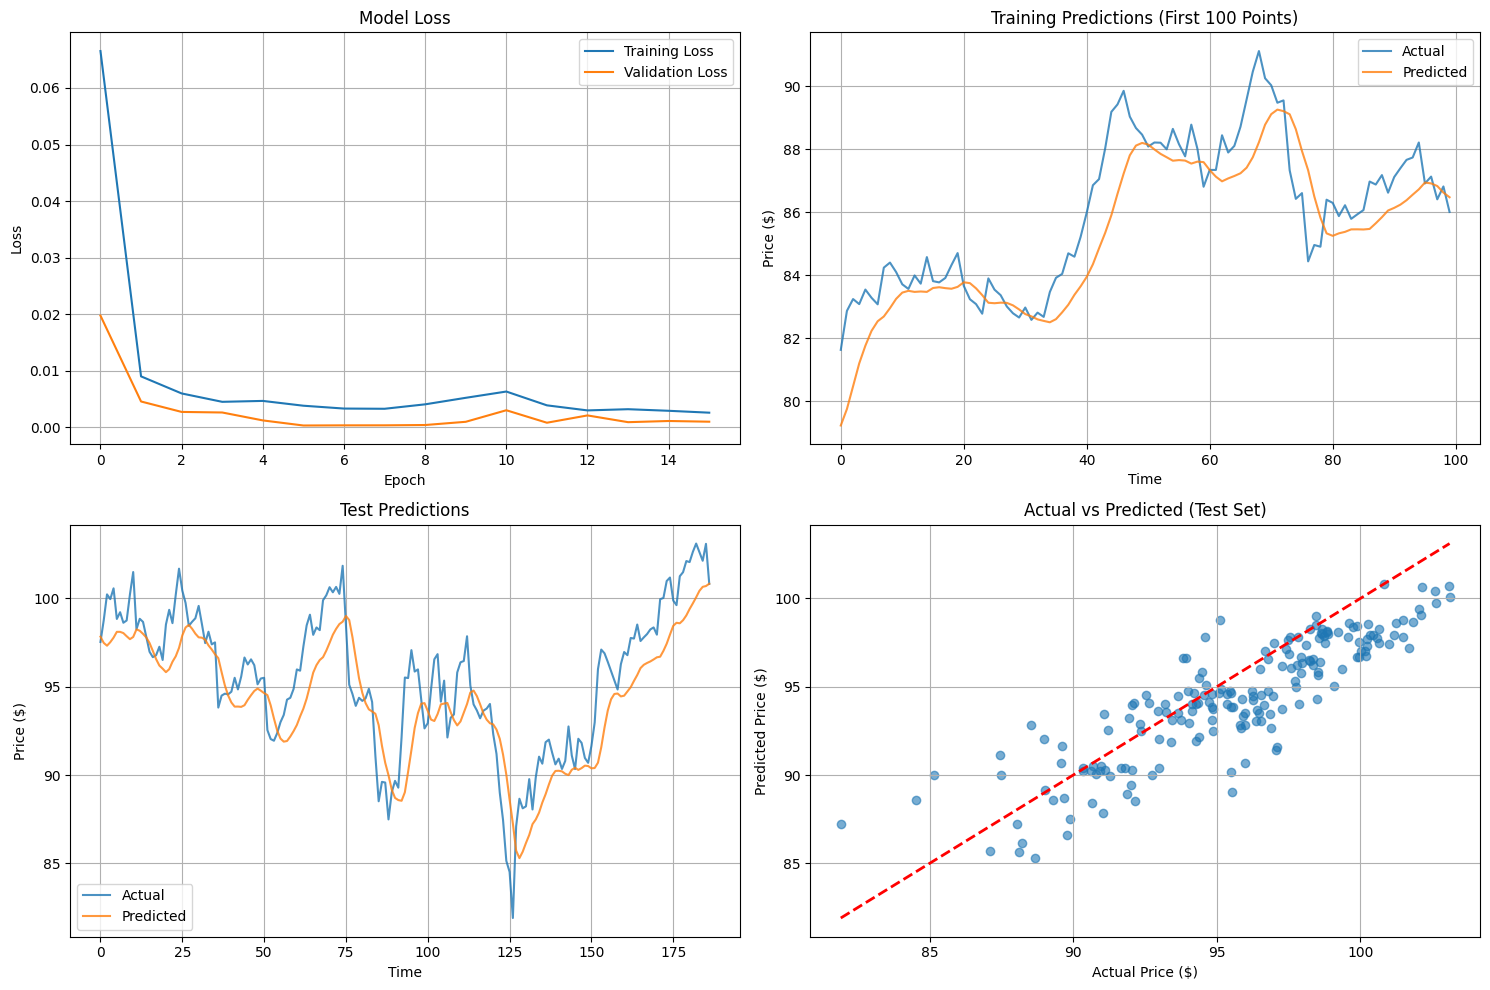

In [58]:
def plot_results(results, history):
    """
    Plot training history and predictions
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Plot 1: Training Loss
    axes[0, 0].plot(history.history['loss'], label='Training Loss')
    axes[0, 0].plot(history.history['val_loss'], label='Validation Loss')
    axes[0, 0].set_title('Model Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    # Plot 2: Training Predictions (first 100 points)
    train_actual = results['train_actual']
    train_predicted = results['train_predicted']
    n_points = min(100, len(train_actual))

    axes[0, 1].plot(train_actual[:n_points], label='Actual', alpha=0.8)
    axes[0, 1].plot(train_predicted[:n_points], label='Predicted', alpha=0.8)
    axes[0, 1].set_title('Training Predictions (First 100 Points)')
    axes[0, 1].set_xlabel('Time')
    axes[0, 1].set_ylabel('Price ($)')
    axes[0, 1].legend()
    axes[0, 1].grid(True)

    # Plot 3: Test Predictions
    test_actual = results['test_actual']
    test_predicted = results['test_predicted']

    axes[1, 0].plot(test_actual, label='Actual', alpha=0.8)
    axes[1, 0].plot(test_predicted, label='Predicted', alpha=0.8)
    axes[1, 0].set_title('Test Predictions')
    axes[1, 0].set_xlabel('Time')
    axes[1, 0].set_ylabel('Price ($)')
    axes[1, 0].legend()
    axes[1, 0].grid(True)

    # Plot 4: Scatter Plot
    axes[1, 1].scatter(test_actual, test_predicted, alpha=0.6)
    axes[1, 1].plot([test_actual.min(), test_actual.max()],
                   [test_actual.min(), test_actual.max()], 'r--', lw=2)
    axes[1, 1].set_title('Actual vs Predicted (Test Set)')
    axes[1, 1].set_xlabel('Actual Price ($)')
    axes[1, 1].set_ylabel('Predicted Price ($)')
    axes[1, 1].grid(True)

    plt.tight_layout()
    plt.show()

# Plot results if available
if 'results' in locals() and 'history' in locals():
    print("Plotting results...")
    plot_results(results, history)
else:
    print("Cannot plot results - results not available")


Hyperparameter Tuning

In [59]:
def hyperparameter_tuning(X_train, y_train, scaler, n_trials=5):
    """
    Simple hyperparameter tuning
    """
    best_model = None
    best_loss = float('inf')
    best_units = None

    units_options = [32, 50, 64, 100]

    print("Starting hyperparameter tuning...")

    for units in units_options:
        print(f"\nTesting with {units} GRU units...")

        # Build model
        test_model = build_gru_model((X_train.shape[1], 1), units)

        # Train model
        early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

        history = test_model.fit(
            X_train, y_train,
            epochs=30,
            batch_size=32,
            validation_split=0.2,
            verbose=0,
            callbacks=[early_stopping],
            shuffle=False
        )

        # Get best validation loss
        val_loss = min(history.history['val_loss'])
        print(f"Validation loss: {val_loss:.6f}")

        if val_loss < best_loss:
            best_loss = val_loss
            best_model = test_model
            best_units = units
            print(f"New best model with {units} units!")

    print(f"\nBest configuration: {best_units} units with validation loss: {best_loss:.6f}")
    return best_model, best_units

# Run hyperparameter tuning if desired
if 'X_train' in locals() and input("Run hyperparameter tuning? (y/n): ").lower() == 'y':
    tuned_model, best_units = hyperparameter_tuning(X_train, y_train, scaler)

    # Evaluate tuned model
    tuned_results = make_predictions_and_evaluate(tuned_model, X_train, X_test, y_train, y_test, scaler)

    # Plot tuned results
    # Note: You'll need to retrain to get history for plotting
    print("Tuned model evaluation completed")


Run hyperparameter tuning? (y/n): y
Starting hyperparameter tuning...

Testing with 32 GRU units...
Validation loss: 0.000989
New best model with 32 units!

Testing with 50 GRU units...
Validation loss: 0.000291
New best model with 50 units!

Testing with 64 GRU units...
Validation loss: 0.000271
New best model with 64 units!

Testing with 100 GRU units...
Validation loss: 0.000260
New best model with 100 units!

Best configuration: 100 units with validation loss: 0.000260

Training Metrics:
MSE: 2.0857
MAE: 1.0957
RMSE: 1.4442
MAPE: 1.5212%

Testing Metrics:
MSE: 3.6043
MAE: 1.4693
RMSE: 1.8985
MAPE: 1.5566%

Prediction Ranges:
Train actual: $49.74 - $91.28
Train predicted: $53.42 - $90.48
Test actual: $81.90 - $103.11
Test predicted: $85.60 - $102.40
Tuned model evaluation completed


Performance Summary

In [60]:
def create_performance_summary(results):
    """
    Create a comprehensive performance summary
    """
    print("\n" + "="*50)
    print("GRU MODEL PERFORMANCE SUMMARY")
    print("="*50)

    train_metrics = results['train_metrics']
    test_metrics = results['test_metrics']

    summary_data = {
        'Metric': ['MSE', 'MAE', 'RMSE', 'MAPE (%)'],
        'Training': [
            f"{train_metrics['MSE']:.4f}",
            f"{train_metrics['MAE']:.4f}",
            f"{train_metrics['RMSE']:.4f}",
            f"{train_metrics['MAPE']:.4f}"
        ],
        'Testing': [
            f"{test_metrics['MSE']:.4f}",
            f"{test_metrics['MAE']:.4f}",
            f"{test_metrics['RMSE']:.4f}",
            f"{test_metrics['MAPE']:.4f}"
        ]
    }

    df_summary = pd.DataFrame(summary_data)
    print(df_summary.to_string(index=False))

    # Performance analysis
    print(f"\nModel Analysis:")
    print(f"Average prediction error: ${test_metrics['MAE']:.2f}")
    print(f"MAPE (lower is better): {test_metrics['MAPE']:.2f}%")

    if test_metrics['MAPE'] < 5:
        print("Status: Excellent prediction accuracy")
    elif test_metrics['MAPE'] < 10:
        print("Status: Good prediction accuracy")
    else:
        print("Status: Model needs improvement")

# Create summary if results are available
if 'results' in locals():
    create_performance_summary(results)
else:
    print("Cannot create summary - results not available")



GRU MODEL PERFORMANCE SUMMARY
  Metric Training Testing
     MSE   2.4665  5.5249
     MAE   1.1992  1.9281
    RMSE   1.5705  2.3505
MAPE (%)   1.6617  2.0177

Model Analysis:
Average prediction error: $1.93
MAPE (lower is better): 2.02%
Status: Excellent prediction accuracy
